# Building ReAct Agents with LangGraph — Part 1: Hardcoded Agent

**Raz Systems · Agentic AI Engineering Curriculum**

Based on: *"Building ReAct Agents with LangGraph: A Beginner's Guide"* (MachineLearningMastery.com)

---

This notebook builds **Part 1** of a two-part ReAct (Reasoning + Acting) agent series: a hardcoded version that follows a fixed script. The goal is to understand the **mechanics** of the ReAct loop — reason, act, observe, repeat — before adding any real LLM intelligence (that's Part 2).

**Worked example for this notebook:** *"What's the weather and population of Bangalore?"*

The ReAct cycle:

1. **Reasoning** — the agent thinks about what it needs to do next
2. **Acting** — the agent takes an action (here: a mock search)
3. **Observing** — the agent examines the result of that action

This cycle repeats until the agent has gathered enough information to answer.

> **Why hardcoded first?** With fixed, rule-based logic instead of an LLM, you can trace *exactly* what the graph does on every run — no model variability to account for. Once the mechanics click, Part 2 swaps the hardcoded reasoning for an LLM call, and you'll see the graph's *shape* stay identical.

## 1. Setup

In [1]:
from typing import TypedDict, Annotated
import operator

from langgraph.graph import StateGraph, END

## 2. Define the agent's state

`StateGraph` needs a schema describing everything the agent tracks as it runs. We use a `TypedDict`:

- **`messages`** — accumulates every thought, action, and observation. `Annotated[list, operator.add]` tells LangGraph to **append** new messages to the existing list rather than overwriting it (this is a *reducer* — it defines how updates merge into state).
- **`next_action`** — tells the graph which node to run next (`"action"` or `"finish"`).
- **`iterations`** — counts how many reasoning cycles have run, so we can enforce a hard stop.

In [2]:
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]
    next_action: str
    iterations: int

## 3. The mock search tool

In a real ReAct agent, tools perform actions in the world — web search, database queries, API calls. For this hardcoded version, we use a **mock search tool** with hardcoded responses, scoped to our Bangalore example. In production this would call a real search API (Google, Bing, Tavily, etc.).

In [3]:
def mock_search_tool(query: str) -> str:
    """Simulates a search engine with hardcoded responses for our Bangalore example."""
    query_lower = query.lower()

    if "weather" in query_lower and "bangalore" in query_lower:
        return "Bangalore weather: 24°C, partly cloudy, light breeze. Pleasant year-round climate due to elevation (~900m)."

    if "population" in query_lower and "bangalore" in query_lower:
        return "Bangalore population: approximately 13.6 million in the metropolitan area, making it India's 3rd most populous city."

    return f"No specific information found for query: '{query}'"


# Quick sanity check
print(mock_search_tool("weather in Bangalore"))
print(mock_search_tool("population of Bangalore"))

Bangalore weather: 24°C, partly cloudy, light breeze. Pleasant year-round climate due to elevation (~900m).
Bangalore population: approximately 13.6 million in the metropolitan area, making it India's 3rd most populous city.


## 4. The reasoning node (hardcoded logic)

This is where the agent thinks about what to do next. In this simple version, we use **hardcoded rules** based on the iteration count — no LLM involved yet:

- **Iteration 0** → ask about weather
- **Iteration 1** → ask about population
- **Iteration 2+** → we have both pieces of information, so finish

This mimics how a human might approach the task: *"First I need weather info, then population data, then I can answer."*

In [4]:
def reason(state: AgentState) -> dict:
    """Hardcoded reasoning: decides the next query based on iteration count."""
    iteration = state["iterations"]

    if iteration == 0:
        thought = "Thought: I need to find the weather in Bangalore first. QUERY: weather in Bangalore"
        next_action = "action"
    elif iteration == 1:
        thought = "Thought: Now I need the population of Bangalore. QUERY: population of Bangalore"
        next_action = "action"
    else:
        thought = "Thought: I have weather and population data. I can now answer the question."
        next_action = "finish"

    print(f"\n🧠 REASON (iteration {iteration}): {thought}")

    return {
        "messages": [thought],
        "next_action": next_action,
    }

## 5. The action node

Once the reasoning node decides to act, this node executes the chosen action and observes the result:

- **Action** — calls `mock_search_tool` with the query the reasoning node decided on
- **Observation** — records what the tool returned
- **Routing** — sets `next_action` back to `"reasoning"` to continue the loop
- **Iteration increment** — this is also where the iteration counter goes up

In [6]:
def act(state: AgentState) -> dict:
    """Executes the action implied by the most recent thought, then observes the result."""
    last_thought = state["messages"][-1]
    print(f"⚡ ACT: full message '{state["messages"]}'")
    print(f"⚡ ACT: last thought '{last_thought}'")
    # Extract the query (everything after "QUERY:")
    query = last_thought.split("QUERY:")[-1].strip()

    print(f"⚡ ACT: searching for '{query}'")

    observation = mock_search_tool(query)
    print(f"👀 OBSERVE: {observation}")

    return {
        "messages": [f"Observation: {observation}"],
        "next_action": "reasoning",
        "iterations": state["iterations"] + 1,
    }

## 6. The router

LangGraph's conditional edges need a small helper function that reads the state and returns a string — that string is then matched against a routing map to decide which node runs next.

- Enforces a **hard maximum of 3 iterations** to guarantee the loop can't run forever, no matter what `next_action` says
- Otherwise just reads `next_action`, which `reason()` and `act()` have already set

In [7]:
MAX_ITERATIONS = 3

def router(state: AgentState) -> str:
    """Reads next_action and tells LangGraph where to go next."""
    if state["iterations"] >= MAX_ITERATIONS:
        return "finish"
    return state["next_action"]

## 7. Assemble the graph

This is where it all comes together:

1. **Add nodes** — register `reason` and `act` as nodes in the graph
2. **Set entry point** — the graph always starts at `reason`
3. **Add conditional edges** — after `reason`, the router decides: go to `act`, or finish
4. **Add a normal edge** — after `act` always loops back to `reason` (this is the cycle that makes it a *graph*, not just a chain)

In [8]:
graph = StateGraph(AgentState)

# 1. Add nodes
graph.add_node("reasoning", reason)
graph.add_node("action", act)

# 2. Entry point
graph.set_entry_point("reasoning")

# 3. Conditional routing after reasoning
graph.add_conditional_edges(
    "reasoning",
    router,
    {
        "action": "action",
        "finish": END,
    }
)

# 4. Normal edge: after acting, always go back to reasoning
graph.add_edge("action", "reasoning")

# Compile
app = graph.compile()

print("✅ Graph compiled")

✅ Graph compiled


## 8. (Optional) Visualize the graph

If you have the visualization extras installed, this renders the actual graph structure — useful for confirming the loop looks the way you expect before running it.

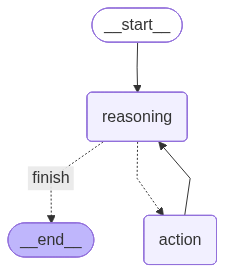

In [8]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization unavailable in this environment:", e)
    print(app.get_graph().draw_mermaid())

## 9. Run the agent

Our worked example: **"What's the weather and population of Bangalore?"**

Watch the iterations — you should see exactly the fixed script we hardcoded: weather first, then population, then finish.

In [9]:
initial_state = {
    "messages": ["Question: What's the weather and population of Bangalore?"],
    "next_action": "reasoning",
    "iterations": 0,
}

print("🚀 STARTING HARDCODED REACT AGENT\n" + "=" * 50)

result = app.invoke(initial_state)

print("\n" + "=" * 50)
print("✅ DONE — full message trace:\n")
for m in result["messages"]:
    print(f"  • {m}")

🚀 STARTING HARDCODED REACT AGENT

🧠 REASON (iteration 0): Thought: I need to find the weather in Bangalore first. QUERY: weather in Bangalore
⚡ ACT: full message '["Question: What's the weather and population of Bangalore?", 'Thought: I need to find the weather in Bangalore first. QUERY: weather in Bangalore']'
⚡ ACT: last thought 'Thought: I need to find the weather in Bangalore first. QUERY: weather in Bangalore'
⚡ ACT: searching for 'weather in Bangalore'
👀 OBSERVE: Bangalore weather: 24°C, partly cloudy, light breeze. Pleasant year-round climate due to elevation (~900m).

🧠 REASON (iteration 1): Thought: Now I need the population of Bangalore. QUERY: population of Bangalore
⚡ ACT: full message '["Question: What's the weather and population of Bangalore?", 'Thought: I need to find the weather in Bangalore first. QUERY: weather in Bangalore', 'Observation: Bangalore weather: 24°C, partly cloudy, light breeze. Pleasant year-round climate due to elevation (~900m).', 'Thought: Now I nee

## 10. What just happened?

Trace through what you saw:

| Step | Node | What it did |
|---|---|---|
| 1 | `reasoning` | Iteration 0 → decided to query weather |
| 2 | `action` | Called `mock_search_tool("weather in Bangalore")`, got a result, incremented iteration |
| 3 | `reasoning` | Iteration 1 → decided to query population |
| 4 | `action` | Called `mock_search_tool("population of Bangalore")`, got a result, incremented iteration |
| 5 | `reasoning` | Iteration 2 → decided it has enough info, set `next_action = "finish"` |
| — | *(router)* | Saw `next_action == "finish"` → routed to `END` |

**The key limitation of this version:** every decision is hardcoded. If you asked a different question — say, *"What's the best time of year to visit Bangalore?"* — this agent would still dutifully search for weather and population, because `reason()` doesn't actually look at the question at all. It just follows the iteration-count script.

**That's exactly the problem Part 2 solves.** Same graph shape — `reasoning → action → reasoning → ...` — but the `reason()` node becomes an LLM call that reads the actual question and decides, dynamically, what to search for next.